In [384]:
import pandas as pd
df = pd.read_csv(r'/kaggle/input/flipkart-product-customer-reviews-dataset/Dataset-SA.csv')

In [385]:
df[["Summary","Rate"]].head()

,Summary,Rate
0,great cooler excellent air flow and for this p...,5
1,best budget 2 fit cooler nice cooling,5
2,the quality is good but the power of air is de...,3
3,very bad product its a only a fan,1
4,ok ok product,3


In [391]:
data = df[["Summary","Sentiment"]]
data.head()

,Summary,Sentiment
0,great cooler excellent air flow and for this p...,positive
1,best budget 2 fit cooler nice cooling,positive
2,the quality is good but the power of air is de...,positive
3,very bad product its a only a fan,negative
4,ok ok product,neutral


In [392]:
data = data.groupby("Sentiment",group_keys=False).apply(lambda x : x.sample(10000))

/tmp/ipykernel_31/676066737.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("Sentiment",group_keys=False).apply(lambda x : x.sample(10000))


In [393]:
data["Sentiment"].value_counts()

Sentiment
negative    10000
neutral     10000
positive    10000
Name: count, dtype: int64

In [275]:
!pip install contractions

In [276]:
import re
import emoji
import contractions
import pandas as pd
import spacy
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score,confusion_matrix
import seaborn as sns
import torch.nn as nn
import string
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [394]:
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his",
              "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", 
              "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
              "having", "do", "does", "did", "doing", "a", "an", "the", "and", "if", "or", "because", "as", "until", "while", "of", "at",
              "by", "for", "with", "about", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from",
              "up", "down", "in", "on", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why",
              "how", "all", "any", "both", "each", "other", "some", "such", "own", "same", 
              "than", "too", "now"]
punctuation_chars = string.punctuation
regrex_pattern = f"[{re.escape(punctuation_chars)}]"
url_pattern = r"https?://\S+|www\.\S+"


In [395]:
def convert_emojis_to_words(text):
    return emoji.demojize(text,delimiters=(" ", " "))
    
def clean_text(text):
    text = convert_emojis_to_words(text)
    text = re.sub(url_pattern,"",text)  #remove URLS
    expanded = contractions.fix(text).lower()
    
    punctuation_remove = re.sub(regrex_pattern,"",expanded)
    cleaned_token = [token for token in punctuation_remove.split(" ") if token not in stop_words]
    return " ".join(cleaned_token)

clean_text( "I'll buy! it even if it isn't cheap.")

'will buy even not cheap'

In [396]:
 data.isna().sum()

Summary      6
Sentiment    0
dtype: int64

In [397]:
data.dropna(inplace=True)

In [398]:
 data.isna().sum()

Summary      0
Sentiment    0
dtype: int64

In [399]:
data["cleaned_text"] = data["Summary"].apply(clean_text)

In [400]:
data["Sentiment"] = data["Sentiment"].map({
    "positive":2,
    "negative":0,
    "neutral":1,
})

In [401]:
data.sample(5)

,Summary,Sentiment,cleaned_text
14113,product is verry good but the cells are missin...,0,product verry good but cells missing remote so...
159095,finishing of bars ms rods are not good,0,finishing bars ms rods not good
48571,cloths quality is very poor,0,cloths quality very poor
163131,good,2,good
140001,ok,1,ok


In [402]:
class Tokenization():
    def __init__(self,data):
        self.data = data
        # print(data)
        all_words = " ".join(self.data).lower().split()

        self.vocab = set(all_words)
        pad_unknown = {"<PAD>":0,"<UNK>":1}
        self.word2idx = {word: i+2 for i, word in enumerate(self.vocab)}  #  0 for padding and 1 for Unknown
        self.word2idx.update(pad_unknown)

    def encode(self,text):
        encoded = []
        for word in text.lower().split():
            if word in self.vocab:
                encoded.append(self.word2idx[word])
            else:
                encoded.append(1)
            
        return encoded

    def decode(self,encode_text):
        print(encode_text)
        decode_list = []
        for token in encode_text:
            for key,value in self.word2idx.items():
                if token==value:
                    decode_list.append(key)
        return " ".join(decode_list)
                    



In [403]:
token = Tokenization(data["cleaned_text"])
data["encoded_text"] = data["cleaned_text"].apply(token.encode)

In [404]:
# Padding: making each list sentence of equal length
def padding_text(text, max_length=64):
    if ((max_length - len(text)) < 0):
        return text[:max_length-len(text)]
    padded_sequence = text + [0] * (max_length - len(text))
    return padded_sequence

data["padded_text"] = data["encoded_text"].apply(padding_text,args=(64,))

In [405]:
data.rename(columns={
    "Summary":"Review",
    "Sentiment":"Rating"
},inplace=True)

In [406]:
data.sample(5)

,Review,Rating,cleaned_text,encoded_text,padded_text
185648,this cost is not suitable for it this is waste...,0,cost not suitable waste product,"[6154, 6773, 11324, 12920, 3069]","[6154, 6773, 11324, 12920, 3069, 0, 0, 0, 0, 0..."
125309,not good defective and used protect recive,0,not good defective used protect recive,"[6773, 8461, 2126, 12985, 1866, 1962]","[6773, 8461, 2126, 12985, 1866, 1962, 0, 0, 0,..."
4564,such a valuable product value for money sounds...,2,valuable product value money sounds good also ...,"[3146, 3069, 2535, 6183, 4797, 8461, 10869, 21...","[3146, 3069, 2535, 6183, 4797, 8461, 10869, 21..."
128058,its get hot very quickly,0,get hot very quickly,"[12531, 7296, 12452, 6615]","[12531, 7296, 12452, 6615, 0, 0, 0, 0, 0, 0, 0..."
79586,this is really a value for money producti have...,2,really value money producti using oil long tim...,"[14448, 2535, 6183, 3339, 7732, 490, 8975, 256...","[14448, 2535, 6183, 3339, 7732, 490, 8975, 256..."


In [414]:
data[["Review","Rating","cleaned_text"]].sample(5)

,Review,Rating,cleaned_text
95118,fast comparable original charger from infinix ...,2,fast comparable original charger infinix thank...
116505,not working properly,0,not working properly
161224,too small n quantity also,1,small n quantity also
99154,value for money,2,value money
171844,wast padokcat,1,wast padokcat


In [412]:
train, test = train_test_split(data[["padded_text","Sentiment"]],test_size=0.15, random_state=42)

KeyError: "['Sentiment'] not in index"

In [289]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.inputs = data["padded_text"].reset_index(drop=True)
        self.targets = data["Sentiment"].reset_index(drop=True)
        
    def __len__(self):        
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx], dtype=torch.long), torch.tensor(self.targets[idx], dtype=torch.long)



In [290]:
train_dataset = SentimentDataset(train)
test_dataset = SentimentDataset(test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [291]:
class CustomLSTMCell(nn.Module):
    def __init__(self,input_size, hidden_size):
        super(CustomLSTMCell,self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        #gate's Fully connected network
        self.forget_linear = nn.Linear(self.input_size+self.hidden_size,self.hidden_size)
        self.input_linear_sigmoid = nn.Linear(self.input_size+self.hidden_size,self.hidden_size)
        self.forget_linear_tanh = nn.Linear(self.input_size+self.hidden_size,self.hidden_size)
        self.output_linear_sigmoid = nn.Linear(self.input_size+self.hidden_size,self.hidden_size)

    def forward(self, x, hidden_state, cell_state):
        self.input_hidden = torch.concat([x,hidden_state],dim=1)
        
        # forget gate 
        f_t = self.forget_linear(self.input_hidden)
        f_t = torch.sigmoid(f_t)

        #input gate
        i_t = self.input_linear_sigmoid(self.input_hidden)
        i_t = torch.sigmoid(i_t)

        ic_t = self.forget_linear_tanh(self.input_hidden)
        ic_t = torch.tanh(ic_t)

        #output_gate
        o_t = self.output_linear_sigmoid(self.input_hidden)
        o_t = torch.sigmoid(o_t)

        i_ic = i_t * ic_t  #point_wise multiply input to lstm cell state

        c_t = cell_state * f_t  + i_ic  #cell state of current lstm

        h_t = o_t * torch.tanh(c_t)   #hidden state of current lstm [batch, hidden_size]

        return h_t, c_t


class CustomLSTM(nn.Module):
    def __init__(self,input_size, hidden_size):
        super(CustomLSTM,self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.LSTM_cell = CustomLSTMCell(self.input_size,self.hidden_size)

    def forward(self,x):
        batch,padded_size,embedding_dim = x.shape
        h_t = torch.zeros(batch,self.hidden_size).to(x.device)  #initializing hidden state
        c_t = torch.zeros(batch,self.hidden_size).to(x.device)   #initializing cell state

        outputs = []  
        
        #loop through each word in sequence to their find hidden_state
        for t in range(padded_size):
            x_t = x[:, t, :]
            h_t, c_t = self.LSTM_cell(x_t, h_t, c_t)
            outputs.append(h_t.unsqueeze(1))  #[batch,1,hidden_size]
        outputs = torch.cat(outputs, dim=1)  # (batch, seq_len, hidden_size)
        # print(outputs.shape)
        return outputs

In [292]:
class Attention(nn.Module):
    def __init__(self,input_size):
        super(Attention,self).__init__()
        self.hidden_size = input_size
        self.attention = nn.Linear(self.hidden_size,1)
    
    def forward(self, x):
        attention_score = self.attention(x)    #[batch,seq_len,1]

        attention_weight = torch.softmax(attention_score.squeeze(-1),dim=1)  #softmax on sequence to calculate probability [batch,seq_len]
        attn_weights_expanded = attention_weight.unsqueeze(-1)  #[batch,seq_len] --> [batch,seq_len, 1]  [[[1],[2],[3]]]=[1,3,1]

        weighted_output = x * attn_weights_expanded     #hidden state multiply with atten_weight => [batch,seq_len,hidden_state] * 
                                                        #[batch,seq_len,hidden_state] * [batch,seq_len,1] = 
                                                        # [batch,seq_len,hidden_state] this determine the importance of each word in sequence

        context_vector = weighted_output.sum(dim=1)     #find the summary of sequence [batch,hidden_state]

        return context_vector, attention_weight

In [293]:
class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_dim, padding_idx):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm1 = CustomLSTM(embedding_dim, hidden_size)
        self.lstm2 = CustomLSTM(64, hidden_size)
        self.fc = nn.Linear(hidden_size, output_dim)
        self.attention = Attention(hidden_size)
    def forward(self,x):
        x = self.embedding(x)
        x = self.lstm1(x)
        x = self.lstm2(x)
        x, attn_weight = self.attention(x)
        x = self.fc(x)
        return torch.softmax(x,dim=1)
        
model = SentimentModel(len(token.vocab)+2, 100, 64, 3, 0).to(device)
    

In [343]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        # lstm_output shape: [seq_len, batch, hidden_size]
        attn_weights = self.attn(lstm_output)  # [seq_len, batch, 1]
        attn_weights = torch.softmax(attn_weights, dim=0)  # attention across seq_len
        context = torch.sum(attn_weights * lstm_output, dim=0)  # [batch, hidden_size]
        return context, attn_weights


class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_dim, padding_idx):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm1 = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.attention = Attention(hidden_size)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x, return_attn=False):
        x = self.embedding(x)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x.transpose(0, 1)  
        context, attn_weights = self.attention(x)  # context: [batch, hidden], attn_weights: [seq_len, batch, 1]
        output = self.fc(context)
    
        if return_attn:
            return output, attn_weights
        return output


In [344]:
vocab_size = len(token.vocab) + 2  # +2 for padding and unknown
embedding_dim = 100
hidden_size = 128
output_dim = 3
padding_idx = 0

model = SentimentModel(vocab_size, embedding_dim, hidden_size, output_dim, padding_idx).to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [345]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0004)
criterion = nn.CrossEntropyLoss()
loss_list = []
for epoch in range(40):
    model.train()
    total_loss = 0

    for texts, labels in train_loader:
        texts = texts.to(device)
        labels = labels.to(device)
        preds = model(texts)  # shape: [batch_size, output_dim]
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
    loss_list.append(total_loss)
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 943.6589
Epoch 2, Loss: 692.7766
Epoch 3, Loss: 619.0316
Epoch 4, Loss: 554.7805
Epoch 5, Loss: 506.1382
Epoch 6, Loss: 454.5930
Epoch 7, Loss: 412.2707
Epoch 8, Loss: 370.8788
Epoch 9, Loss: 337.1405
Epoch 10, Loss: 306.0856
Epoch 11, Loss: 282.4111
Epoch 12, Loss: 263.0153
Epoch 13, Loss: 248.6705
Epoch 14, Loss: 232.4710
Epoch 15, Loss: 221.9959
Epoch 16, Loss: 212.7803
Epoch 17, Loss: 202.4224
Epoch 18, Loss: 203.1203
Epoch 19, Loss: 190.2463
Epoch 20, Loss: 186.1367
Epoch 21, Loss: 178.2890
Epoch 22, Loss: 176.8788
Epoch 23, Loss: 171.0544
Epoch 24, Loss: 167.1450
Epoch 25, Loss: 165.8368
Epoch 26, Loss: 166.4342
Epoch 27, Loss: 158.4034
Epoch 28, Loss: 158.8901
Epoch 29, Loss: 157.2534
Epoch 30, Loss: 151.3262
Epoch 31, Loss: 153.1011
Epoch 32, Loss: 149.0567
Epoch 33, Loss: 147.1034
Epoch 34, Loss: 148.0749
Epoch 35, Loss: 146.2319
Epoch 36, Loss: 142.1961
Epoch 37, Loss: 140.8749
Epoch 38, Loss: 144.6557
Epoch 39, Loss: 141.0781
Epoch 40, Loss: 137.7902


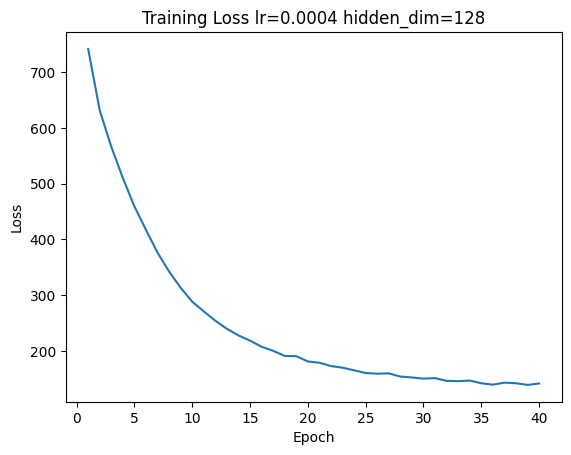

In [313]:
plt.plot(range(1,len(loss_list)+1),np.array(loss_list))
plt.title("Training Loss lr=0.0004 hidden_dim=128")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Total test dataset:  4500
Accuracy: 0.8471
F1 Score: 0.8438


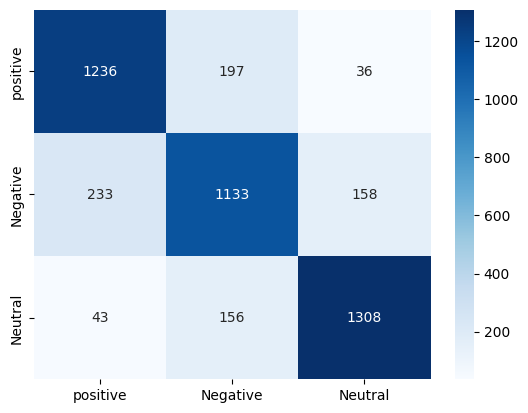

In [347]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        outputs = model(texts)  # shape: [batch_size, num_classes]
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
class_names = ["positive","Negative","Neutral"]
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')  # or 'macro', 'micro'
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

print(f"Total test dataset: ",len(test))
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


In [348]:
def predict(text,model):
    text = clean_text(text)
    encode = token.encode(text)
    padding = padding_text(encode)
    model.eval()
    text_tensor = torch.tensor([padding], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(text_tensor)  # raw logits
        probs = torch.softmax(outputs, dim=1)  # convert to probabilities
        preds = torch.argmax(probs, dim=1)     # get predicted class index
        if (preds[0]==0):
            print("Negative")
        elif (preds[0]==1):
            print("Neutral")
        else:
            print("Positive")

    return preds.cpu(), probs.cpu()
    

In [315]:
predict("i like this clothes but i not color", model)

Neutral


(tensor([1]), tensor([[6.5861e-05, 9.9965e-01, 2.8883e-04]]))

In [320]:
def predict(texts,model):
    text_df = pd.Series(texts)
    clean = text_df.apply(clean_text)
    encode = clean.apply(token.encode)
    padding = encode.apply(padding_text)
    model.eval()
    text_tensor = torch.tensor(padding, dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(text_tensor)  # raw logits
        probs = torch.softmax(outputs, dim=1)  # convert to probabilities
        preds = torch.argmax(probs, dim=1)     # get predicted class index
        

    return preds.cpu()
    

In [336]:
def label(texts,predict):
    for x,i in zip(texts,predict):
        if (i==0):
            print(f"{x} \n \033[1m NEGATIVE\n")
        elif (i==1):
            print(f"{x}\n \033[1m NEUTRAL \n")
        else:
            print(f"{x}\n \033[1m POSITIVE \n")

In [339]:
demo_text = [
    "I love this clothes but i not the color",
    "This is the best product",
    "ok",
    "Nice product",
    "The battery is not good"
]
demo_predict = predict(demo_text, model)
label(demo_text,demo_predict)

I love this clothes but i not the color
  NEUTRAL 

This is the best product
  POSITIVE 

ok
  NEUTRAL 

Nice product
  POSITIVE 

The battery is not good 
  NEGATIVE



Counter({1: 2, 2: 2, 0: 1})


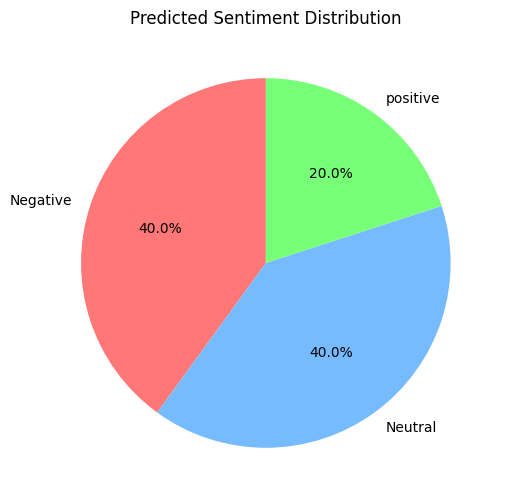

In [340]:
lass_names = ['Negative', 'Neutral', 'Positive']
counts = Counter(demo_predict.tolist())
labels = [class_names[label] for label in counts.keys()]
print(counts)
sizes = list(counts.values())
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#f77', '#7bf', '#7f7'])
plt.title("Predicted Sentiment Distribution")
plt.show()

In [303]:
def get_attention(model, input_tensor, device):
    model.eval()
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output, attn_weights = model(input_tensor, return_attn=True)  # [seq_len, batch, 1]

    attn_weights = attn_weights.squeeze(-1).squeeze(1)  # shape: [seq_len]
    return attn_weights.cpu().numpy()


In [304]:
def plot_attention(input_tokens, attention_weights, pad_token="<PAD>"):
    input_tokens = input_tokens.split(" ")
    # Filter out <pad> tokens
    filtered_tokens = []
    filtered_weights = []

    for tok, weight in zip(input_tokens, attention_weights):
        if tok != pad_token:
            filtered_tokens.append(tok)
            filtered_weights.append(weight)
    print(filtered_tokens)

    # Plot
    plt.figure(figsize=(5,5))
    plt.bar(range(len(filtered_weights)), filtered_weights, tick_label=filtered_tokens)
    plt.xticks(rotation=45)
    plt.title("Attention Weights (excluding <pad>)")
    plt.xlabel("Input Tokens")
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()


In [305]:
a = torch.tensor([test["padded_text"].iloc[89]], dtype=torch.long)

tensor([ 6747,  4245,  8453,  6747, 13118,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])
['not', 'so', 'good', 'not', 'buy']


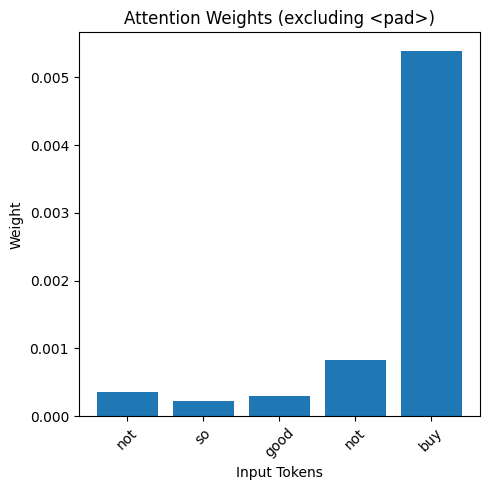

In [306]:
attn_weight = get_attention(model,a,device)
plot_attention(token.decode(a[0]),attn_weight)

In [415]:
torch.save(model, '/kaggle/working/sentiment_model.pth')